# Customer Churn Prediction

## Business Problem

Customer churn is one of the most significant challenges faced by subscription-based businesses. Acquiring new customers is often more expensive than retaining existing ones. This project aims to identify customers who are likely to discontinue the service, enabling the company to take proactive retention measures.

## Objective

The objective of this project is to build a machine learning model that predicts customer churn using demographic information, service usage, and billing data from the `Telco Customer Churn Dataset.`

## Import Libraries

In [28]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

## Load Dataset

In [2]:
df = pd.read_csv('Telco_Customer_Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Dataset Overview

The Telco Customer Churn Dataset contains information about telecom customers, including demographic details, subscribed services, billing information, and churn status.

Dataset Characteristics:
- Rows: 7043
- Columns: 21
- Target Variable: Churn

The dataset contains:

- Customer demographics (gender, senior citizen, partner, dependents)
- Services (internet, phone, online security, tech support, etc.)
- Billing information (monthly charges, total charges, contract type)

### Data Cleaning

The dataset was inspected for missing values, duplicate records, and incorrect data types before model development.

In [6]:
df['TotalCharges'].dtype

dtype('O')

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],
                                   errors="coerce")

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.duplicated().sum()

0

In [11]:
df.drop("customerID", axis=1, inplace=True)

### Data Cleaning Summary

- Converted `TotalCharges` from object type to numeric
- Handled invalid entries created during conversion
- No missing values were present initially, but conversion introduced invalid values which were handled
- Verified no duplicate records
- Removed `customerID` as it is not useful for prediction

## Exploratory Data Analysis (EDA)

In [12]:
df["Churn"].value_counts()

No     5163
Yes    1869
Name: Churn, dtype: int64

### Churn Distribution

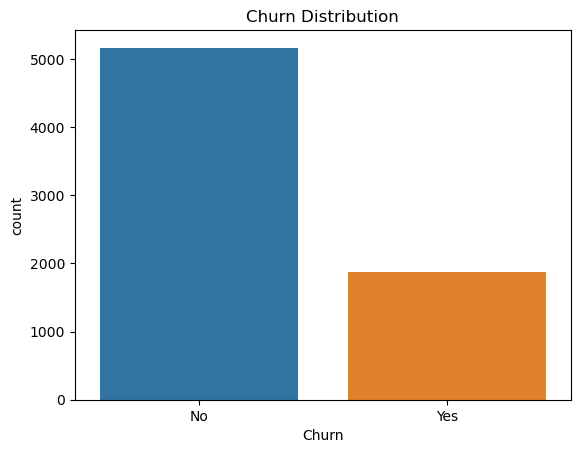

In [13]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Insight

**The dataset is moderately imbalanced, with a larger proportion of customers remaining with the company than leaving. This imbalance should be considered when evaluating model performance.**

To address this, class weights were applied during model training to improve the model’s ability to correctly identify churned customers.

### Contract vs Churn

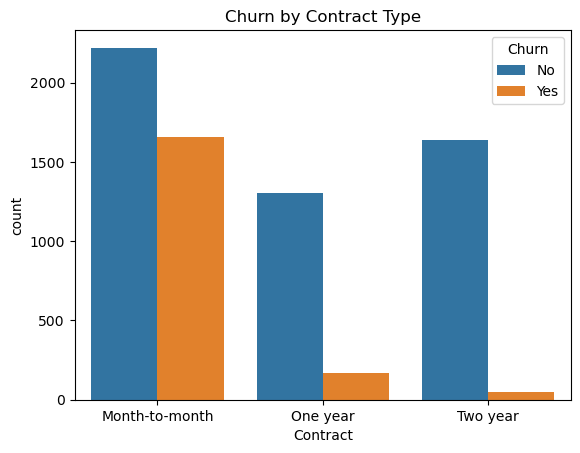

In [14]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

### Insight

**Customers with month-to-month contracts have the highest churn rate. Long-term contracts (one-year and two-year) show significantly lower churn, suggesting that customer commitment reduces churn.**

### Tenure vs Churn

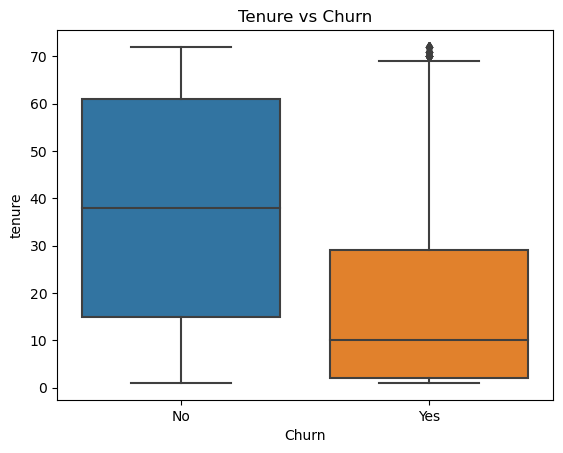

In [15]:
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Tenure vs Churn")
plt.show()

### Insight

**Customers with shorter tenure are more likely to discontinue the service. This suggests that the early stages of the customer lifecycle are critical for retention.**

### Monthly Charges vs Churn

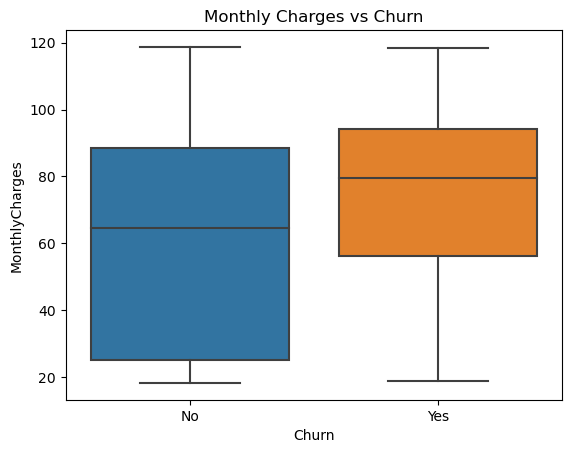

In [16]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Insight

**Customers with higher monthly charges exhibit a greater tendency to churn. This may indicate pricing dissatisfaction or perceived lack of value relative to the cost of the service.**

### Tech Support vs Churn

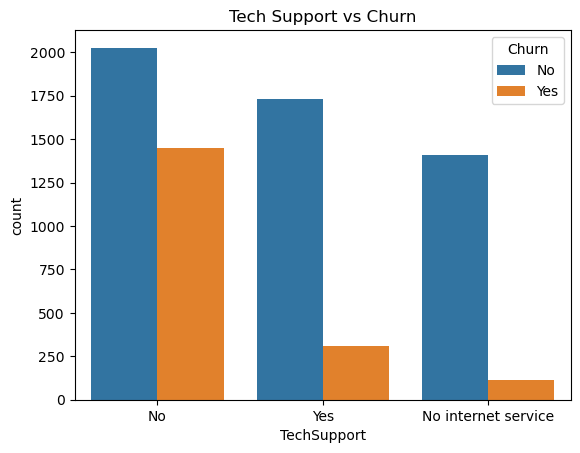

In [17]:
sns.countplot(x="TechSupport",hue="Churn",data=df)
plt.title("Tech Support vs Churn")
plt.show()

### Insight

**Customers without technical support services show significantly higher churn rates. Providing effective customer support may improve customer satisfaction and reduce churn.**

## Feature Engineering

To prepare the dataset for machine learning:
- Convert target variable
- Applied One-Hot Encoding for categorical variables
- Converted all features into numerical format for machine learning
- Final dataset was used for model training

In [18]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


### Train-Test Split
- Split ratio: 80% training, 20% testing
- Random state = 42 for reproducibility

In [21]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Scaling
Scaling improves convergence for Logistic Regression; not strictly required for Random Forest but applied for consistency.

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model 1: Logistic Regression
- Used as baseline model
- Simple and interpretable
- Class imbalance was handled using class weights to improve recall for churn customers.

In [23]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



## Model 2: Random Forest
- Used to capture non-linear relationships
- Class imbalance was handled using class weights to improve recall for churn customers.

In [24]:
rf = RandomForestClassifier(n_estimators=300,max_depth=10,
                            class_weight="balanced",random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.52      0.70      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



## Feature Importance

In [26]:
importances = rf.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

                           Feature  Importance
1                           tenure    0.178895
3                     TotalCharges    0.145141
2                   MonthlyCharges    0.107877
25               Contract_Two year    0.096424
10     InternetService_Fiber optic    0.065220
28  PaymentMethod_Electronic check    0.044540
24               Contract_One year    0.044488
13              OnlineSecurity_Yes    0.033985
19                 TechSupport_Yes    0.026366
26            PaperlessBilling_Yes    0.017392


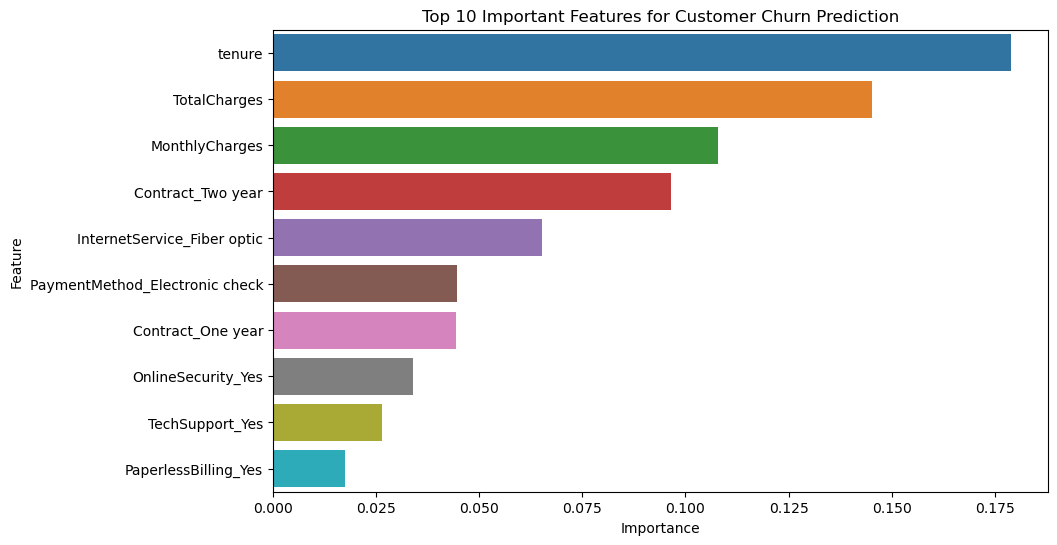

In [27]:
#Top 10 Important Features

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top_features)
plt.title("Top 10 Important Features for Customer Churn Prediction")
plt.show()

### Insight
- Tenure is the most influential factor in predicting churn
- Contract type significantly affects customer retention
- Monthly charges also contribute strongly to churn behavior
- Service-related features like tech support and internet service play a key role

## Model Comparison


|  model            |Accuracy|Precision|Recall|F1-score|
|-------------------|--------|---------|------|--------|
|Logistic Regression|	 0.73|	   0.50|  0.79|	   0.61|
|Random Forest	    |    0.75|	   0.52|  0.70|	   0.60|

## Key Insights

- Customers with short tenure are most likely to churn
- Month-to-month contracts significantly increase churn risk
- Higher monthly charges increase churn probability
- Lack of tech support services increases churn
- Customer engagement in early lifecycle is critical

## Business Recommendations

- Promote long-term contracts (discount incentives)
- Improve onboarding experience (first 3 months critical)
- Bundle tech support + security services
- Identify high-risk customers early using model
- Provide personalized offers for high-risk users

## Final Conclusion

This project demonstrates a complete machine learning pipeline for predicting customer churn.

**Key Findings:**
- Customer tenure is the strongest predictor of churn
- Month-to-month contracts significantly increase churn probability
- High monthly charges increase churn risk
- Lack of support services increases customer loss

**Final Decision:**

- Random Forest selected due to better balance between precision and recall
- Recall prioritized due to business importance of identifying churn customers